In [ ]:
import numpy as np
import tensorflow as tf
seed = 2022
tf.random.set_seed(seed)
np.random.seed(seed)

1) Cifar 10 수업에서 사용했던 모델

In [ ]:
from tensorflow.keras.datasets import cifar100
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

169017344/169001437 [==============================] - 4s 0us/step


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

In [ ]:
class_names=['apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle','chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur','dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','keyboard','lamp','lawn_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain','mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree','plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket','rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider','squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor','train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm']

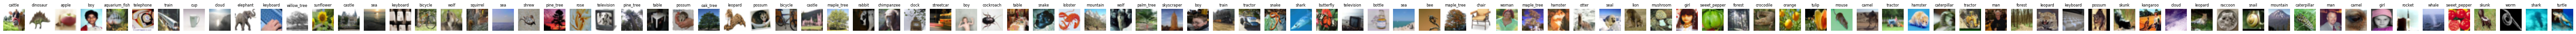

In [ ]:
plt.figure(figsize=(100,20))
for i in range(100):
    plt.subplot(1,100,i+1)
    plt.imshow(X_train[i]), plt.axis('off')
    plt.title(class_names[y_train[i,0]], fontsize=8)
plt.show()

In [ ]:
# X_data: scaling
X_train = X_train / 255.
X_test = X_test / 255.

In [ ]:
# y_data: one hot encoding
from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)

In [ ]:
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import RMSprop

In [ ]:
model = Sequential([
                    Conv2D(32, (3,3), input_shape=(32,32,3), padding='same', activation='relu'),
                    Conv2D(32, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Conv2D(64, (3,3), padding='same', activation='relu'),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dropout(0.5),
                    Dense(100, activation='softmax')
])
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 conv2d_17 (Conv2D)          (None, 30, 30, 32)        9248      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 dropout_12 (Dropout)        (None, 15, 15, 32)        0         
                                                                 
 conv2d_18 (Conv2D)          (None, 15, 15, 64)        18496     
                                                                 
 conv2d_19 (Conv2D)          (None, 13, 13, 64)        36928     
                                                      

In [ ]:
model.compile(optimizer=RMSprop(learning_rate=0.0001, decay=1e-6),
              loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model_path = 'best-cifar100_v1.h5'
mc = ModelCheckpoint(model_path, save_best_only=True, verbose=1)
es = EarlyStopping(patience=10)

In [ ]:
hist = model.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[mc,es])

Epoch 1/100
1242/1250 [============================>.] - ETA: 0s - loss: 4.3731 - accuracy: 0.0367
Epoch 1: val_loss improved from inf to 4.14008, saving model to best-cifar100_v1.h5
1250/1250 [==============================] - 19s 6ms/step - loss: 4.3720 - accuracy: 0.0368 - val_loss: 4.1401 - val_accuracy: 0.0766
Epoch 2/100
1243/1250 [============================>.] - ETA: 0s - loss: 3.9967 - accuracy: 0.0881
Epoch 2: val_loss improved from 4.14008 to 3.76401, saving model to best-cifar100_v1.h5
1250/1250 [==============================] - 8s 6ms/step - loss: 3.9957 - accuracy: 0.0883 - val_loss: 3.7640 - val_accuracy: 0.1396
Epoch 3/100
1241/1250 [============================>.] - ETA: 0s - loss: 3.7258 - accuracy: 0.1318
Epoch 3: val_loss improved from 3.76401 to 3.55512, saving model to best-cifar100_v1.h5
1250/1250 [==============================] - 8s 6ms/step - loss: 3.7247 - accuracy: 0.1322 - val_loss: 3.5551 - val_accuracy: 0.1710
Epoch 4/100
1242/1250 [====================

In [ ]:
best_model = load_model(model_path)
best_model.evaluate(X_test, Y_test)

313/313 [==============================] - 1s 4ms/step - loss: 2.1711 - accuracy: 0.4481


[2.171077251434326, 0.4481000006198883]

In [ ]:
y_acc = hist.history['accuracy']
y_vloss = hist.history['val_loss']
xs = np.arange(1,len(y_acc)+1)

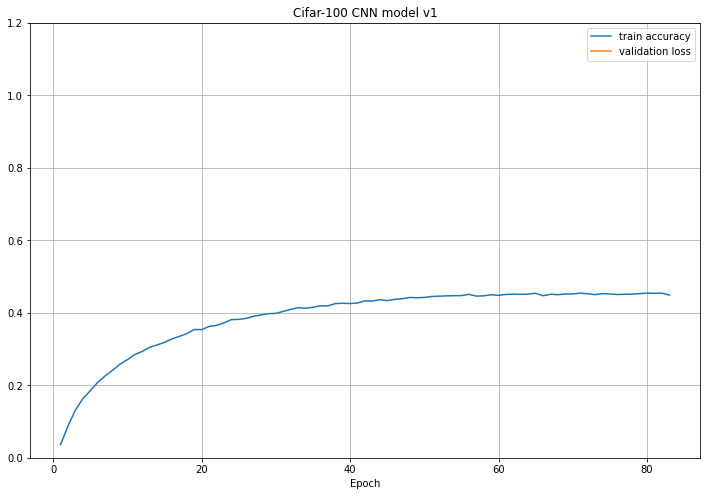

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(xs, y_acc, label='train accuracy')
plt.plot(xs, y_vloss, label='validation loss')
plt.legend(), plt.grid(), plt.ylim(0,1.2),
plt.xlabel('Epoch')
plt.title('Cifar-100 CNN model v1')
plt.show()

2) 새로운 모델: Conv2D 노드를 모두 32개로 통일
 - dropout을 모두 0.25로 통일

In [ ]:
model1 = Sequential([
                    Conv2D(32, (3,3), input_shape=(32,32,3), padding='same', activation='relu'),
                    Conv2D(32, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Conv2D(32, (3,3), padding='same', activation='relu'),
                    Conv2D(32, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dropout(0.25),
                    Dense(100, activation='softmax')
])
model1.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 conv2d_21 (Conv2D)          (None, 30, 30, 32)        9248      
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 15, 15, 32)       0         
 g2D)                                                            
                                                                 
 dropout_15 (Dropout)        (None, 15, 15, 32)        0         
                                                                 
 conv2d_22 (Conv2D)          (None, 15, 15, 32)        9248      
                                                                 
 conv2d_23 (Conv2D)          (None, 13, 13, 32)        9248      
                                                      

In [ ]:
model1.compile(optimizer=RMSprop(learning_rate=0.0001, decay=1e-6),
              loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model_path1 = 'best-cifar100_v2.h5'
mc1 = ModelCheckpoint(model_path1, save_best_only=True, verbose=1)
es1= EarlyStopping(patience=10)

In [ ]:
hist1 = model1.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[mc1,es1])

Epoch 1/100
1240/1250 [============================>.] - ETA: 0s - loss: 4.3264 - accuracy: 0.0419
Epoch 1: val_loss improved from inf to 4.09269, saving model to best-cifar100_v2.h5
1250/1250 [==============================] - 8s 6ms/step - loss: 4.3252 - accuracy: 0.0421 - val_loss: 4.0927 - val_accuracy: 0.0877
Epoch 2/100
1250/1250 [==============================] - ETA: 0s - loss: 3.9737 - accuracy: 0.0945
Epoch 2: val_loss improved from 4.09269 to 3.76963, saving model to best-cifar100_v2.h5
1250/1250 [==============================] - 7s 6ms/step - loss: 3.9737 - accuracy: 0.0945 - val_loss: 3.7696 - val_accuracy: 0.1444
Epoch 3/100
1250/1250 [==============================] - ETA: 0s - loss: 3.7025 - accuracy: 0.1419
Epoch 3: val_loss improved from 3.76963 to 3.56305, saving model to best-cifar100_v2.h5
1250/1250 [==============================] - 7s 6ms/step - loss: 3.7025 - accuracy: 0.1419 - val_loss: 3.5631 - val_accuracy: 0.1686
Epoch 4/100
1250/1250 [=====================

In [ ]:
best_model1 = load_model(model_path1)
best_model1.evaluate(X_test, Y_test)

313/313 [==============================] - 1s 3ms/step - loss: 2.1970 - accuracy: 0.4461


[2.1969945430755615, 0.44609999656677246]

In [ ]:
y_acc1 = hist1.history['accuracy']
y_vloss1 = hist1.history['val_loss']
xs1 = np.arange(1,len(y_acc1)+1)

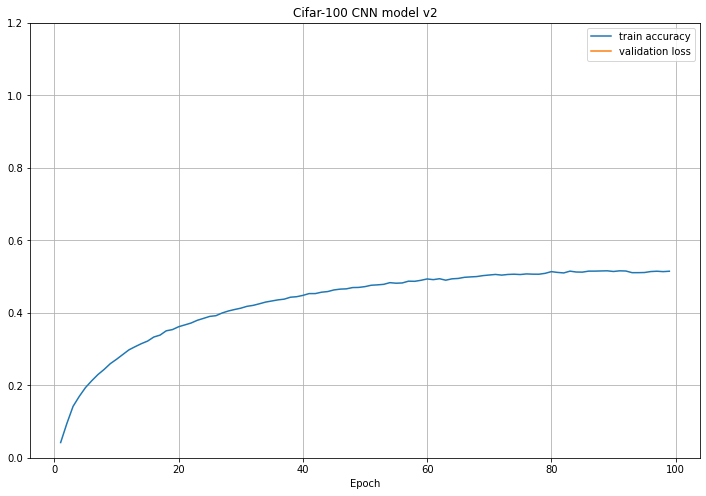

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(xs1, y_acc1, label='train accuracy')
plt.plot(xs1, y_vloss1, label='validation loss')
plt.legend(), plt.grid(), plt.ylim(0,1.2),
plt.xlabel('Epoch')
plt.title('Cifar-100 CNN model v2')
plt.show()

2-2)새로운 모델: Conv2D 노드를 모두 64개로 통일
 - dropout을 0.25로 통일

In [ ]:
model2 = Sequential([
                    Conv2D(64, (3,3), input_shape=(32,32,3), padding='same', activation='relu'),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Conv2D(64, (3,3), padding='same', activation='relu'),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dropout(0.25),
                    Dense(100, activation='softmax')
])
model2.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 32, 32, 64)        1792      
                                                                 
 conv2d_25 (Conv2D)          (None, 30, 30, 64)        36928     
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 15, 15, 64)       0         
 g2D)                                                            
                                                                 
 dropout_18 (Dropout)        (None, 15, 15, 64)        0         
                                                                 
 conv2d_26 (Conv2D)          (None, 15, 15, 64)        36928     
                                                                 
 conv2d_27 (Conv2D)          (None, 13, 13, 64)        36928     
                                                      

In [ ]:
model2.compile(optimizer=RMSprop(learning_rate=0.0001, decay=1e-6),
              loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model_path2 = 'best-cifar100_v3.h5'
mc2 = ModelCheckpoint(model_path2, save_best_only=True, verbose=1)
es2= EarlyStopping(patience=10)

In [ ]:
hist2 = model2.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[mc2,es2])

Epoch 1/100
1247/1250 [============================>.] - ETA: 0s - loss: 4.2712 - accuracy: 0.0516
Epoch 1: val_loss improved from inf to 3.93497, saving model to best-cifar100_v3.h5
1250/1250 [==============================] - 11s 8ms/step - loss: 4.2708 - accuracy: 0.0516 - val_loss: 3.9350 - val_accuracy: 0.1120
Epoch 2/100
1246/1250 [============================>.] - ETA: 0s - loss: 3.7797 - accuracy: 0.1248
Epoch 2: val_loss improved from 3.93497 to 3.55259, saving model to best-cifar100_v3.h5
1250/1250 [==============================] - 10s 8ms/step - loss: 3.7798 - accuracy: 0.1248 - val_loss: 3.5526 - val_accuracy: 0.1741
Epoch 3/100
1245/1250 [============================>.] - ETA: 0s - loss: 3.5061 - accuracy: 0.1720
Epoch 3: val_loss improved from 3.55259 to 3.34709, saving model to best-cifar100_v3.h5
1250/1250 [==============================] - 10s 8ms/step - loss: 3.5059 - accuracy: 0.1722 - val_loss: 3.3471 - val_accuracy: 0.2070
Epoch 4/100
1244/1250 [==================

In [ ]:
best_model2 = load_model(model_path2)
best_model2.evaluate(X_test, Y_test)

313/313 [==============================] - 2s 4ms/step - loss: 2.1700 - accuracy: 0.4575


[2.169989585876465, 0.45750001072883606]

In [ ]:
y_acc2 = hist2.history['accuracy']
y_vloss2 = hist2.history['val_loss']
xs2 = np.arange(1,len(y_acc2)+1)

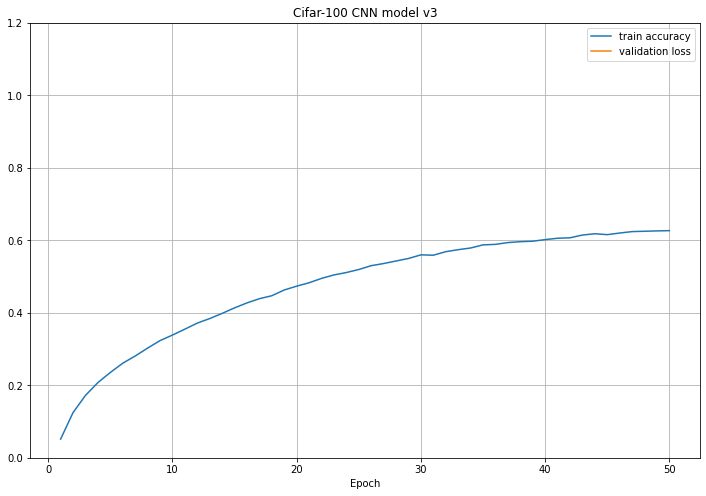

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(xs2, y_acc2, label='train accuracy')
plt.plot(xs2, y_vloss2, label='validation loss')
plt.legend(), plt.grid(), plt.ylim(0,1.2),
plt.xlabel('Epoch')
plt.title('Cifar-100 CNN model v3')
plt.show()

2) 새로운 모델: Conv2D 노드를 모두 128개로 통일
 - dropout은 0.25로 통일

In [ ]:
model3 = Sequential([
                    Conv2D(128, (3,3), input_shape=(32,32,3), padding='same', activation='relu'),
                    Conv2D(128, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Conv2D(128, (3,3), padding='same', activation='relu'),
                    Conv2D(128, (3,3), activation='relu'),
                    MaxPooling2D(),
                    Dropout(0.25),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dropout(0.25),
                    Dense(100, activation='softmax')
])
model3.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_28 (Conv2D)          (None, 32, 32, 128)       3584      
                                                                 
 conv2d_29 (Conv2D)          (None, 30, 30, 128)       147584    
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 15, 15, 128)      0         
 g2D)                                                            
                                                                 
 dropout_21 (Dropout)        (None, 15, 15, 128)       0         
                                                                 
 conv2d_30 (Conv2D)          (None, 15, 15, 128)       147584    
                                                                 
 conv2d_31 (Conv2D)          (None, 13, 13, 128)       147584    
                                                      

In [ ]:
model3.compile(optimizer=RMSprop(learning_rate=0.0001, decay=1e-6),
              loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model_path3 = 'best-cifar100_v4.h5'
mc3 = ModelCheckpoint(model_path3, save_best_only=True, verbose=1)
es3= EarlyStopping(patience=10)

In [ ]:
hist3 = model3.fit(X_train, Y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[mc3,es3])

Epoch 1/100
1249/1250 [============================>.] - ETA: 0s - loss: 4.1564 - accuracy: 0.0707
Epoch 1: val_loss improved from inf to 3.79504, saving model to best-cifar100_v4.h5
1250/1250 [==============================] - 18s 14ms/step - loss: 4.1560 - accuracy: 0.0707 - val_loss: 3.7950 - val_accuracy: 0.1304
Epoch 2/100
1246/1250 [============================>.] - ETA: 0s - loss: 3.5959 - accuracy: 0.1540
Epoch 2: val_loss improved from 3.79504 to 3.35900, saving model to best-cifar100_v4.h5
1250/1250 [==============================] - 17s 13ms/step - loss: 3.5960 - accuracy: 0.1540 - val_loss: 3.3590 - val_accuracy: 0.2071
Epoch 3/100
1248/1250 [============================>.] - ETA: 0s - loss: 3.2842 - accuracy: 0.2132
Epoch 3: val_loss improved from 3.35900 to 3.09016, saving model to best-cifar100_v4.h5
1250/1250 [==============================] - 17s 13ms/step - loss: 3.2840 - accuracy: 0.2132 - val_loss: 3.0902 - val_accuracy: 0.2558
Epoch 4/100
1250/1250 [===============

In [ ]:
best_model3 = load_model(model_path3)
best_model3.evaluate(X_test, Y_test)

313/313 [==============================] - 13s 42ms/step - loss: 2.1349 - accuracy: 0.4605


[2.134939193725586, 0.46050000190734863]

In [ ]:
y_acc3 = hist3.history['accuracy']
y_vloss3 = hist3.history['val_loss']
xs3 = np.arange(1,len(y_acc3)+1)

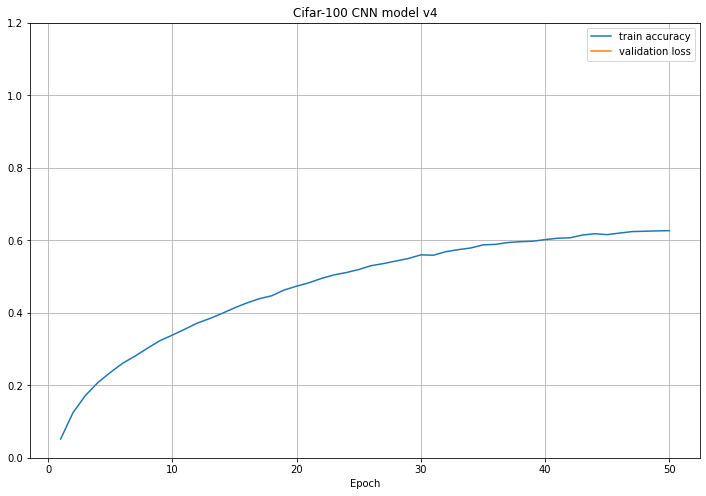

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(xs2, y_acc2, label='train accuracy')
plt.plot(xs2, y_vloss2, label='validation loss')
plt.legend(), plt.grid(), plt.ylim(0,1.2),
plt.xlabel('Epoch')
plt.title('Cifar-100 CNN model v4')
plt.show()

2) 새로운 모델: Conv2D 노드를 모두 128개로 통일

- dropout은 0.25로 통일
- 옵티마이저를 아담으로

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Multi/220525/권기일.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Multi/220525/권기일.ipynb to html
[NbConvertApp] Writing 1144944 bytes to /content/drive/MyDrive/Multi/220525/권기일.html
